In [1]:
# Step 1: Install and Import Libraries
!pip install nltk

# Import the required libraries
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\rumsh\AppData\Roaming\nltk_data...


In [3]:
# Sample dataset of product reviews
reviews = [
    "This product is amazing! It exceeded all my expectations.",
    "Absolutely terrible! I will never buy this again.",
    "The quality is outstanding. I highly recommend it.",
    "Worst purchase I've ever made. It broke within a week.",
    "Great value for money. I'm very happy with it.",
    "Completely useless. Don't waste your money.",
    "I'm impressed with how durable this is.",
    "Terrible customer service. Very disappointing experience."
]

In [7]:
# Initialize the VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Analyze sentiment for each review
sentiment_scores = []
for review in reviews:
    scores = sia.polarity_scores(review)  # Get sentiment scores
    sentiment_scores.append(scores)

# Convert the results to a DataFrame for better visualization
sentiment_df = pd.DataFrame(sentiment_scores)
sentiment_df['Review'] = reviews

# Display the DataFrame
sentiment_df

,neg,neu,pos,compound,Review
0,0.000,0.662,0.338,0.6239,This product is amazing! It exceeded all my ex...
1,0.380,0.620,0.000,-0.5697,Absolutely terrible! I will never buy this again.
2,0.000,0.424,0.576,0.7778,The quality is outstanding. I highly recommend...
3,0.496,0.504,0.000,-0.7845,Worst purchase I've ever made. It broke within...
4,0.000,0.364,0.636,0.8883,Great value for money. I'm very happy with it.
5,0.319,0.413,0.268,-0.1274,Completely useless. Don't waste your money.
6,0.000,0.659,0.341,0.4767,I'm impressed with how durable this is.
7,0.622,0.378,0.000,-0.7645,Terrible customer service. Very disappointing ...


In [9]:
# Function to categorize sentiment
def categorize_sentiment(compound):
    if compound > 0.05:
        return "Positive"
    elif compound < -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply the function to categorize sentiment
sentiment_df['Category'] = sentiment_df['compound'].apply(categorize_sentiment)

# Display the updated DataFrame
sentiment_df

,neg,neu,pos,compound,Review,Category
0,0.000,0.662,0.338,0.6239,This product is amazing! It exceeded all my ex...,Positive
1,0.380,0.620,0.000,-0.5697,Absolutely terrible! I will never buy this again.,Negative
2,0.000,0.424,0.576,0.7778,The quality is outstanding. I highly recommend...,Positive
3,0.496,0.504,0.000,-0.7845,Worst purchase I've ever made. It broke within...,Negative
4,0.000,0.364,0.636,0.8883,Great value for money. I'm very happy with it.,Positive
5,0.319,0.413,0.268,-0.1274,Completely useless. Don't waste your money.,Negative
6,0.000,0.659,0.341,0.4767,I'm impressed with how durable this is.,Positive
7,0.622,0.378,0.000,-0.7645,Terrible customer service. Very disappointing ...,Negative


C:\Users\rumsh\AppData\Local\Temp\ipykernel_21916\2045061950.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=sentiment_df, palette='coolwarm')


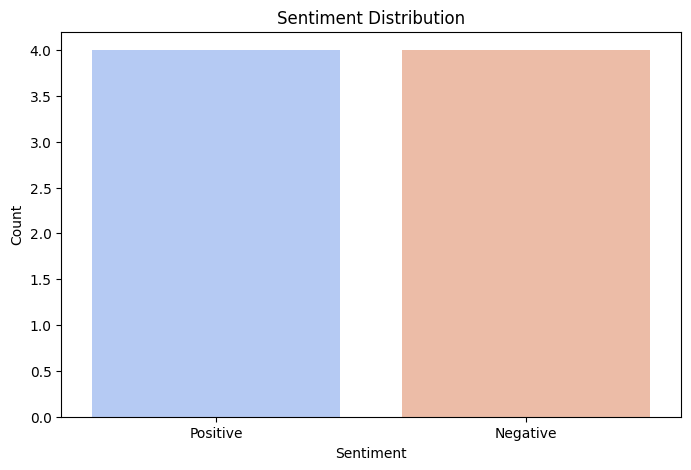

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of sentiment categories
plt.figure(figsize=(8, 5))
sns.countplot(x='Category', data=sentiment_df, palette='coolwarm')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()